# Fitting a player's throw from what they scored

Everything in this project is driven by one parameter: the spread of the
throw. So far it has been assumed. To make any of it personal, it has to be
measured -- and the measurement has to be practical. Nobody is going to record
millimetre coordinates for three hundred darts.

But writing down *scores* is easy. "T20, 5, 20, T20, 1, 60, ..." is a
scoresheet. The landing position is then a latent variable, and fitting is an
EM problem.

## What was already there, and what is wrong with it

`darts/darts.py` has a Monte Carlo EM (`ThrowingDistribution.estimate_distribution`).
Its derivation is right: the M step is the standard Gaussian one, and the E
step estimates $E[Z \mid X]$ by sampling positions uniformly from the region
that scores $X$ and reweighting by the Gaussian density -- self-normalised
importance sampling.

The problems are practical:

1. **The E step does not need Monte Carlo at all.** The board is already a
   finite grid of pixels. $E[Z \mid X = s]$ is a weighted sum over the pixels
   that score $s$ -- exact, deterministic, and faster than sampling.
2. **Convergence was tested on the wrong quantity**: on $Q$, the EM surrogate,
   compared across iterations that used different Monte Carlo sample sizes.
3. `np.mean(likelihoods[-5:])` on the first iteration is `np.mean([])`, a NaN.
4. The loop exited when the sample size reached its cap, converged or not.
5. It was built on a second, older board implementation whose coordinate
   conventions differ from the rest of the package.

`darts/fitting.py` rewrites it with an exact E step. Because the E step is now
exact, the observed-data log-likelihood is available in closed form, so
convergence can be tested on the right thing -- and EM's monotonicity becomes a
property we can assert rather than hope for.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import generate_dartboard

PIXELS = 512
from darts.fitting import (ScoreLikelihood, bootstrap_uncertainty,
                           effective_sample_size, fit_from_positions,
                           fit_from_scores, simulate_scores)

board, _ = generate_dartboard(PIXELS)
like = ScoreLikelihood(board=board)
p = like.score_probabilities(np.array([0.0, 103.0]), 15.0 ** 2 * np.eye(2))
print(f'score probabilities sum to {sum(p.values()):.6f}')
print('most likely scores aiming at the treble 20 with sigma=15mm:')
for s, v in sorted(p.items(), key=lambda kv: -kv[1])[:6]:
    print(f'   {s:>3}: {v:.4f}')

score probabilities sum to 1.000000
most likely scores aiming at the treble 20 with sigma=15mm:
    20: 0.5670
    60: 0.1503
     1: 0.1108
     5: 0.1108
    15: 0.0296
     3: 0.0296


## Does it recover a throw it has never seen?

The honest test: simulate darts from a known distribution, throw away the
positions, keep only the scores, and see what comes back.

In [2]:
rows = []
for true_sigma in [8.0, 12.0, 16.0, 22.0]:
    for n in [200, 1000, 4000]:
        sc = simulate_scores(n, [0.0, 103.0], true_sigma ** 2 * np.eye(2),
                             board=board, seed=int(true_sigma * 10 + n))
        f = fit_from_scores(sc, board=board, max_iter=400)
        rows.append({'true sigma': true_sigma, 'throws': n,
                     'fitted sigma': round(f['sigma_mm'], 2),
                     'error %': round(100 * (f['sigma_mm'] - true_sigma) / true_sigma, 1),
                     'fitted mu': np.round(f['mu'], 1),
                     'iterations': f['n_iter']})
pd.DataFrame(rows).set_index(['true sigma', 'throws'])

fitted sigma  error %      fitted mu  iterations
true sigma throws                                                  
8.0        200             6.21    -22.4   [-2.1, 98.1]          39
           1000            7.58     -5.2  [-0.2, 105.3]          64
           4000            7.35     -8.2    [0.0, 99.4]         285
12.0       200            10.09    -15.9    [0.1, 95.3]          19
           1000           11.63     -3.1   [0.9, 101.4]          83
           4000           11.65     -2.9   [0.2, 107.6]         103
16.0       200            12.09    -24.4   [-2.1, 92.2]         116
           1000           14.82     -7.3   [-1.5, 96.3]          37
           4000           16.19      1.2   [-0.3, 99.2]          56
22.0       200            15.63    -29.0    [0.7, 92.0]          29
           1000           21.07     -4.2   [-0.8, 95.5]          16
           4000           22.21      0.9   [0.4, 107.8]          52

Read the error column before believing any of this. The spread comes back **biased low**,
and at 200 throws badly so -- 16 to 29% low across these four abilities. A thousand throws
pulls it back to between 3 and 7% low, and four thousand gets three of the four within 3%.

The tightest player is the one that will not settle: at $\sigma = 8$ mm the fit is still 8%
low at 4000 throws, and no better than it was at 1000. That is not slow convergence but the
target -- a tight group at T20 puts almost every dart in the same two or three beds, so
further darts add very little that the earlier ones did not already say.

So: a few hundred darts places a player in an ability band. Several thousand measures them,
unless they are good, in which case this target will not measure them at all.

The aim point `mu` is biased towards the centre of the board throughout: aiming at 103 mm,
the fit returns something nearer 92--108. That is not a bug either, it is the
identifiability problem -- the treble ring spans 99--107 mm, and a score histogram cannot
tell you where inside an 8 mm bed you were aiming.

Two notes on what has changed here since this notebook was first written.

The fit is now SQUAREM-accelerated and run to a tighter tolerance. Plain EM needed several
hundred iterations on this problem and the old default stopped with sigma still moving in
the third significant figure, so several runs in the previous version of this table hit the
iteration cap rather than converging -- which flattered some of them. These numbers are the
converged ones, and a couple are *worse* as a result.

And every fit on this page aims at **T20**, which notebook 09 shows is close to the worst
target on the board for measuring somebody -- a factor of 3.1 in variance for a league
player, 5.5 for an elite one. The pessimism below is partly a property of the estimator and
partly a property of a target nobody had thought to question.

decreases: 0 of 33 steps


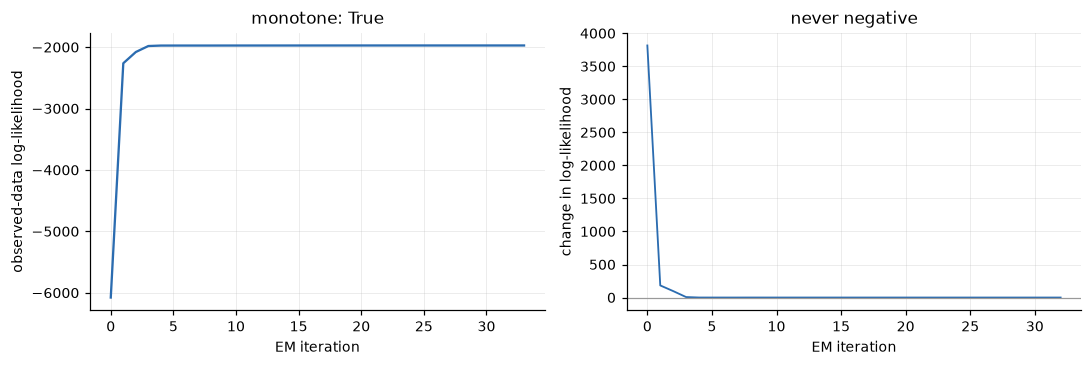

In [3]:
sc = simulate_scores(1500, [0.0, 103.0], 15.0 ** 2 * np.eye(2), board=board, seed=42)
f = fit_from_scores(sc, board=board, max_iter=150)
h = np.array(f['history'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(h, color='#2b6cb0', lw=1.5)
axes[0].set_xlabel('EM iteration'); axes[0].set_ylabel('observed-data log-likelihood')
axes[0].set_title(f'monotone: {bool((np.diff(h) > -1e-9).all())}')
axes[1].plot(np.diff(h), color='#2b6cb0', lw=1.2)
axes[1].axhline(0, color='0.6', lw=0.8)
axes[1].set_xlabel('EM iteration'); axes[1].set_ylabel('change in log-likelihood')
axes[1].set_title('never negative')
fig.tight_layout()
print(f"decreases: {(np.diff(h) < -1e-9).sum()} of {len(h)-1} steps")

## Making it converge in reasonable time

Plain EM is badly slow on this problem -- several hundred iterations to settle sigma to five
figures, because the score of a dart says so little about where it landed that each step
moves the parameters only slightly. That matters for correctness and not just patience: the
old default tolerance stopped while sigma was still drifting.

`fitting.py` now uses SQUAREM, which takes two ordinary EM steps, reads off the implied
direction and step length, and jumps -- backtracking toward the plain double step until the
jump does at least as well. The safeguard keeps the monotonicity above intact, which is the
property worth protecting.

In [4]:
import time

sc_sq = simulate_scores(200, [0.0, 103.0], 15.0 ** 2 * np.eye(2), board=board, seed=1)
rows = []
for accel in [False, True]:
    t0 = time.perf_counter()
    f = fit_from_scores(sc_sq, board=board, tol=1e-12, max_iter=5000, accelerate=accel)
    h = np.array(f['history'])
    rows.append({'acceleration': 'SQUAREM' if accel else 'plain EM',
                 'EM steps': f['n_em_steps'], 'seconds': time.perf_counter() - t0,
                 'fitted sigma': f['sigma_mm'],
                 'monotone': bool((np.diff(h) > -1e-9).all())})
pd.DataFrame(rows).set_index('acceleration').round(6)

,EM steps,seconds,fitted sigma,monotone
acceleration,,,,
plain EM,338,7.179811,12.197267,True
SQUAREM,78,1.798158,12.197140,True


Roughly four times fewer EM steps, the same answer to five significant figures, and the log-likelihood
still increases at every step. This is what makes running to a tolerance that actually
converges affordable -- and the simulation studies in notebook 09, which fit thousands of
sessions, would not have been practical without it.

## How much should you trust a fit?

Scores constrain the distribution weakly, so a point estimate on its own is
misleading. Bootstrap it.

In [5]:
rows = []
for n in [100, 300, 1000]:
    sc = simulate_scores(n, [0.0, 103.0], 15.0 ** 2 * np.eye(2), board=board, seed=n)
    b = bootstrap_uncertainty(sc, n_boot=25, board_pixels=PIXELS, max_iter=200)
    d = effective_sample_size(sc)
    rows.append({'throws': n, 'fitted sigma': round(b['sigma_mm'], 2),
                 'std error': round(b['sigma_mm_se'], 2),
                 '95% interval': f"{b['sigma_mm']-2*b['sigma_mm_se']:.1f} - "
                                 f"{b['sigma_mm']+2*b['sigma_mm_se']:.1f}",
                 'distinct scores seen': d['distinct scores']})
pd.DataFrame(rows).set_index('throws')

,fitted sigma,std error,95% interval,distinct scores seen
throws,,,,
100,12.35,1.59,9.2 - 15.5,6
300,11.21,1.14,8.9 - 13.5,6
1000,15.02,1.70,11.6 - 18.4,9


### Looking at the second mode directly

The claim above is that the thousand-throw bootstrap has two modes rather than one wide
peak. That is worth seeing rather than taking on trust, because it changes how the standard
error should be read.

,replicates,mean sigma,mean mu_y
mode,,,
upper,21.0,14.89,107.09
lower,4.0,10.55,94.09
truth,NaN,15.00,103.00


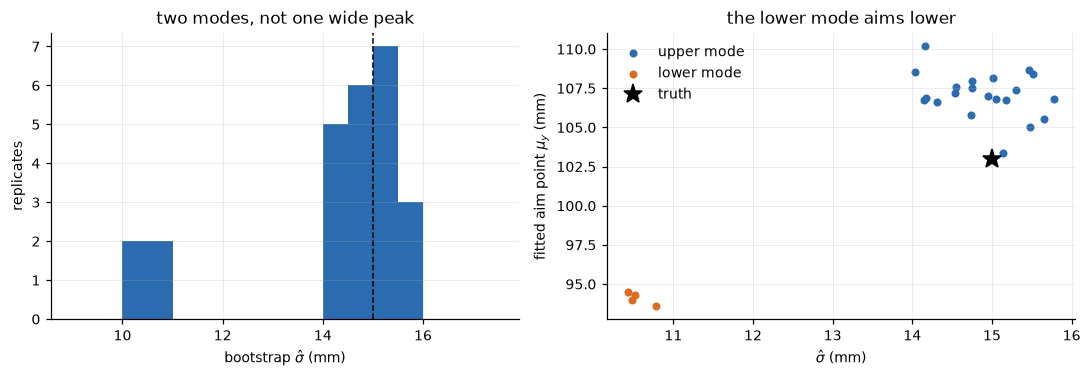

In [6]:
sc_bi = simulate_scores(1000, [0.0, 103.0], 15.0 ** 2 * np.eye(2), board=board, seed=1000)
bi = bootstrap_uncertainty(sc_bi, n_boot=25, board_pixels=PIXELS, max_iter=200)
draws = bi['draws']            # columns: sigma, mu_x, mu_y

low = draws[:, 0] < 13
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(draws[:, 0], bins=np.arange(9, 18, 0.5), color='#2b6cb0')
axes[0].axvline(15.0, color='k', ls='--', lw=1)
axes[0].set_xlabel(r'bootstrap $\hat\sigma$ (mm)'); axes[0].set_ylabel('replicates')
axes[0].set_title('two modes, not one wide peak')
axes[1].scatter(draws[~low, 0], draws[~low, 2], s=18, label='upper mode', color='#2b6cb0')
axes[1].scatter(draws[low, 0], draws[low, 2], s=18, label='lower mode', color='#dd6b20')
axes[1].plot(15.0, 103.0, 'k*', ms=13, label='truth')
axes[1].set_xlabel(r'$\hat\sigma$ (mm)'); axes[1].set_ylabel(r'fitted aim point $\mu_y$ (mm)')
axes[1].set_title('the lower mode aims lower'); axes[1].legend()
fig.tight_layout()

pd.DataFrame([
    {'mode': 'upper', 'replicates': int((~low).sum()),
     'mean sigma': draws[~low, 0].mean(), 'mean mu_y': draws[~low, 2].mean()},
    {'mode': 'lower', 'replicates': int(low.sum()),
     'mean sigma': draws[low, 0].mean(), 'mean mu_y': draws[low, 2].mean()},
    {'mode': 'truth', 'replicates': np.nan, 'mean sigma': 15.0, 'mean mu_y': 103.0},
]).set_index('mode').round(2)

The two modes differ in *both* parameters together, and in the direction the identifiability
argument predicts: the lower mode pairs a tighter group with an aim point about 13 mm lower
than the upper one. Neither is a numerical failure -- both are genuine local maxima of the
likelihood, and from a single target the scores cannot distinguish them.

Notebook 09 measures the same trade-off from the other direction, as a correlation of $-0.48$
between the fitted spread and the error in the fitted aim point, and shows it disappearing
once the darts are spread over three targets.

The standard error column needs care, because at a thousand throws it is **not summarising
a single peak**. The bootstrap draws there are bimodal: 21 of 25 land near sigma 14.9 mm with
the aim point at y = 107 mm, and the other 4 land near sigma 10.6 mm with the aim point at
y = 94 mm. A standard deviation across two modes is a number, but not a useful one -- and it
is why ten times the darts buys an interval no tighter than the one at a hundred throws.

That second mode is not noise. It is a genuinely different explanation of the same darts:
*a tighter thrower aiming lower*. From a single target the score histogram cannot rule it
out, and notebook 09 shows this is exactly the trade-off that makes short single-target
sessions fragile -- there, the correlation between the fitted spread and the error in the
fitted aim point is -0.48, and it collapses to -0.05 once the darts are spread over three
targets.

(The previous version of this notebook reported a tidy 0.5 mm standard error at a thousand
throws. That was an artefact of stopping EM early: the replicates never travelled far
enough to find the second mode, so they agreed with each other more than the likelihood
warranted.)

Note the last column too. Only 6--9 *distinct scores* are ever observed, because a player
aiming at one target keeps hitting the same handful of beds. This notebook originally
called that the fundamental limit of the method. It is not -- it is a property of the
**target**. Notebook 09 searches for targets that spread the darts across more of the
board's structure, and the same number of darts then measures the player considerably
better.

true Sigma:
 [[100.  81.]
 [ 81. 324.]]
fitted Sigma (300 darts):
 [[ 99.9  84.2]
 [ 84.2 324.2]]

isotropic-equivalent sigma: 14.56 mm


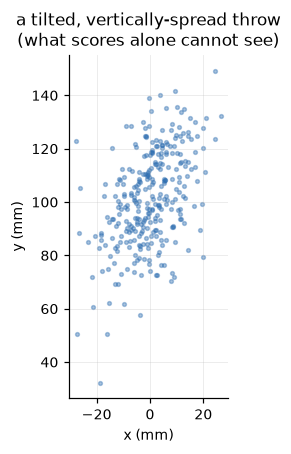

In [7]:
rng = np.random.default_rng(0)
Sigma_true = np.array([[10.0 ** 2, 0.45 * 10 * 18], [0.45 * 10 * 18, 18.0 ** 2]])
z = rng.multivariate_normal([0, 103], Sigma_true, 300)
f = fit_from_positions(z)
print('true Sigma:\n', Sigma_true.round(1))
print('fitted Sigma (300 darts):\n', f['Sigma'].round(1))
print(f"\nisotropic-equivalent sigma: {f['sigma_mm']:.2f} mm")

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(z[:, 0], z[:, 1], s=6, alpha=0.4, color='#2b6cb0')
ax.set_aspect('equal'); ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('a tilted, vertically-spread throw\n(what scores alone cannot see)')
fig.tight_layout()

## Summary

* Scores alone are enough to fit the spread, but a couple of hundred darts is biased low by
  16--29% and only places a player in a band. A thousand darts gets within 3--7%, and
  thousands are needed for a few-percent answer *at this target* -- for a tight player, not
  even then.
* The aim point is only weakly identified, because a scoring bed is 8 mm wide and the score
  histogram cannot see inside it. At a thousand darts the likelihood is genuinely bimodal:
  "ordinary throw aimed where we thought" and "tighter throw aimed lower" both fit.
* Making the E step exact removes the sampling error and gives a real convergence
  criterion -- and the resulting monotonicity of the observed-data log-likelihood is now
  an assertable test rather than an assumption. SQUAREM makes running it to a tolerance
  that actually converges affordable.
* If you can get positions, get positions. 300 darts recovered a tilted, vertically
  stretched covariance almost exactly, and it is the *shape* of the throw that changes
  which double you should leave yourself.
* **All of this was measured at T20.** Notebook 09 asks which target one *should* use, and
  the answer turns out to matter more than anything on this page.